In [3]:
from scipy.spatial.transform import Rotation, RigidTransform
import numpy as np

In [4]:
!pip install scipy

The RF link budget is based on the Friis transmission equation with FSPL. 


$$P_{in} = P_{tx} + G_{r}(\mathbf{\theta_{r}}, \mathbf{x_{r}}, \mathbf{x_{t}})+G_{t} - L_{path}(\mathbf{x_{r}}, \mathbf{x_{t}}) - L_{pol}(\mathbf{\theta_{r}}, \mathbf{\theta_{r}})$$
$$P_{rx} = P_{tx} + G_{r}(\mathbf{\theta_{r}}, \mathbf{x_{r}}, \mathbf{x_{t}})+G_{t} - 2(L_{path}(\mathbf{x_{r}}, \mathbf{x_{t}}) + L_{pol}(\mathbf{\theta_{r}}, \mathbf{\theta_{r}}))$$
$$\text{RSSI}=P_{rx}+\eta_{meas}$$
$$\eta_{meas} \sim N(0, \sigma_{rssi}^{2})$$

- $x_{r}$ is vector from origin to antenna (receiver).
- $x_{t}$ is vector from origin to tag.
- $\theta_{r}$ is antenna (receiver) boresight vector. Assumed to be a unit vector in x-axis at no rotation.
- $\theta_{t}$ is tag orientation vector. Assumed to be a unit vector in x-axis at no rotation.
### Antenna Power, $P_{tx}$
- `antenna_power`: $P_{tx}$ is transmit power (dBm).

### Antenna Gain, $G_{r}$ (dBi)
Losses arising from angle between antenna boresight, and vector from antenna to tag. This angle is $\theta_{b}$.
$$G_{r}(\mathbf{\theta_{r}}, \mathbf{x_{r}}, \mathbf{x_{t}}) = G_{r, peak} - \min(l_{max}, c\cdot\theta_{b})$$
$$\cos{\theta_{b}} = \frac{(\mathbf{x_t}-\mathbf{x_r})\cdot\theta_{r}}{|(\mathbf{x_t}-\mathbf{x_r})||\theta_{r}|}$$
- `antenna_gain_peak`: $G_{r, peak}$ is assumed gain when we have a $0$ angle (i.e. antenna pointed directly at tag. Default of $6$ (dBi)
- `antenna_gain_max_loss`: $l_{max}$ is used to cap our maximum loss. Default of $25$ (dBi)
- `antenna_gain_loss_scaling`: $c$ is to control how much our boresight angle difference impacts the antenna gain. Default of $6$
  

### Tag Gain, $G_{t}$ (dBi)
- `tag_directional_gain`: $G_{t}$ is assumed to typically be negligible. Default of $0$ (dBi)

### Path Loss, $L_{path}$ (dB)
Losses arising from distance between antenna and tag. Loss increases logarithmically with distance.

$$L_{path}(\mathbf{x_{r}}, \mathbf{x_{t}}) = L_{base} + 10\cdot c_{los}\cdot \log_{10}(\max(d_{min}, |\mathbf{x_t}-\mathbf{x_r}|))$$

- `path_loss_base_loss`: $L_{base}$ is the assumed path loss at an effective distance of 0m. Default of $31$ dB
- `path_loss_los_gain`: $c_{los}$ is a parameter used to increase the loss when we do not have line-of-sight. In this implementation, we assume at all times we don't have line of sight. Default of 2.2
- `path_loss_min_distance`: $d_{min}$ is a parameter to ensure we limit the log loss (and do not end up with a huge gain from small distances. Default of 0.2m

### Polarisation Loss, $L_{pol}$ (dB)
Losses arising from differences in polarisation between antenna and tag.

$$L_{pol}(\mathbf{\theta_{r}}, \mathbf{\theta_{r}})=\min(l_{max}, -20\cdot \log_{10}(|\theta_{r}\cdot\theta_{t}|))$$
- `polarization_max_loss`: $l_{max}$ limits how much loss we have from differences in polarisation. Default of $25$ dB

### Calculating Read Probabilities
We sample from this distribution to determine if the tag is successfully read. 

$$P_{read,t}=\sigma\left(\frac{P_{in}-P_{in,\text{ offset}}}{k_{in}}\right)$$
$$P_{read,r}=\sigma\left(\frac{P_{rx}-P_{rx,\text{ offset}}}{k_{rx}}\right)$$

$$P_{read}=P_{read,t}\cdot P_{read,r}$$
- `tx_threshold_power`: $P_{tx}$ at which there is a 50% chance of tag receiving antenna signal. Default of $-15$ (dBm).
- `rx_threshold_power`: $P_{rx}$ at which there is a 50% chance of receiving tag signal. Default of $-75$ (dBm).
- `tx_read_scaling`: Tx sigmoid scaling parameter. Default of 2.
- `rx_read_scaling`: Rx sigmoid scaling parameter. Default of 2.

In [37]:
## Parameter defaults
param_default = {
    'antenna_power': 30,
    'path_loss_los_gain': 2.2,
    'path_loss_base_loss': 31,
    'path_loss_min_distance': 0.2,
    'polarization_max_loss': 25,
    'antenna_gain_peak': 6,
    'antenna_gain_max_loss': 25,
    'antenna_gain_loss_scaling': 6,
    'tag_directional_gain': 0
}

In [39]:
def rssi(scanner_pose, tag_pose, params=param_default):
    scanner_tag_vec = tag_pose.translation - scanner_pose.translation
    scanner_tag_linear_distance = np.linalg.norm(scanner_tag_vec)

    polarization_cos_theta = np.dot(
        scanner_pose.rotation.apply([1,0,0]),
        tag_pose.rotation.apply([1,0,0]))

    antenna_gain_cos_theta = np.dot(
        scanner_tag_vec / scanner_tag_linear_distance, ## normalized
        scanner_pose.rotation.apply([1,0,0])
    )

    antenna_gain = params['antenna_gain_peak'] - min(params['antenna_gain_max_loss'], params['antenna_gain_loss_scaling']*(np.arccos(antenna_gain_cos_theta)**2))

    loss_polarization = min(params['polarization_max_loss'], -20*np.log10(abs(polarization_cos_theta)))

    loss_path = params['path_loss_base_loss'] + 10*params['path_loss_los_gain']*np.log10(max(params['path_loss_min_distance'], scanner_tag_linear_distance))

    t_power = params['antenna_power'] + antenna_gain + params['tag_directional_gain'] - loss_polarization - loss_path
    r_power = params['antenna_power'] + antenna_gain + params['tag_directional_gain'] - 2*(loss_polarization + loss_path)

    return r_power

In [40]:
rot_id = Rotation.from_euler('xyz', [0,0,0])

scanner_pose = RigidTransform.from_components([0,0,0], rot_id)

model_sdf="""		<model name="{name}">
			<static>true</static>
			<pose> {x} {y} {z} 0 0 0</pose>
			<plugin filename="librfidTag" name="RFIDTagPlugin">
				<uid>{name}</uid>
				<data>{data}</data>
			</plugin>
		</model>
"""

sdf_head="""<?xml version="1.0" ?>
<sdf version="1.9">
	<world name="{world_name}">
		<physics name="1ms" type="ignore">
			<max_step_size>0.001</max_step_size>
			<real_time_factor>1.0</real_time_factor>
		</physics>

		<plugin filename="gz-sim-physics-system" name="gz::sim::systems::Physics"></plugin>
		<plugin filename="gz-sim-sensors-system" name="gz::sim::systems::Sensors">
			<render_engine>ogre2</render_engine>
		</plugin>

		<plugin filename="gz-sim-user-commands-system" name="gz::sim::systems::UserCommands"></plugin>

		<model name="scanner">
			<static>true</static>
			<pose>0 0 0 0 0 0</pose>
			<plugin filename="librfidScanner" name="RFIDScannerPlugin">
				<antenna_power>30</antenna_power>
				<path_loss_los_gain>2.2</path_loss_los_gain>
				<path_loss_base_loss>31</path_loss_base_loss>
				<path_loss_min_distance>0.2</path_loss_min_distance>
				<polarization_max_loss>25</polarization_max_loss>
				<antenna_gain_peak>6</antenna_gain_peak>
				<antenna_gain_max_loss>25</antenna_gain_max_loss>
				<antenna_gain_loss_scaling>6</antenna_gain_loss_scaling>
				<tag_directional_gain>0</tag_directional_gain>

				<tx_threshold_power>-15</tx_threshold_power>
				<rx_threshold_power>-75</rx_threshold_power>
				<tx_read_scaling>2</tx_read_scaling>
				<rx_read_scaling>2</rx_read_scaling>
				<return_all>true</return_all>
			</plugin>
		</model>
"""

sdf_tail="""	</world>
</sdf>
"""

sdf_full = sdf_head.format(world_name="rssi_test_standard")

## Create an std::map, and a corresponding sdf for our poses
idx=0
for i in range(1,6):
     for j in range(1,6):
         for k in range(1,6):
             rpower = rssi(scanner_pose, RigidTransform.from_components([i, j, k], rot_id))
             print(f'{{"tag{idx}", {rpower}}},')

             sdf_full += model_sdf.format(name=f"tag{idx}", x=i, y=j, z=k, data=f"tag {idx} data")
             idx += 1

sdf_full += sdf_tail
with open('worlds/rssi_test_default.sdf', "w") as wfile:
    wfile.write(sdf_full)
   

{"tag0", -41.97244664902168},
{"tag1", -51.05794340312833},
{"tag2", -58.5046882386425},
{"tag3", -64.27501304869871},
{"tag4", -68.86905767322217},
{"tag5", -51.05794340312833},
{"tag6", -56.0849017305048},
{"tag7", -61.35866354521818},
{"tag8", -66.03692366498962},
{"tag9", -70.04248274183837},
{"tag10", -58.5046882386425},
{"tag11", -61.35866354521818},
{"tag12", -64.89523092605351},
{"tag13", -68.44679165522894},
{"tag14", -71.74546304149592},
{"tag15", -64.27501304869871},
{"tag16", -66.03692366498962},
{"tag17", -68.44679165522894},
{"tag18", -71.09730946978087},
{"tag19", -73.73967960965335},
{"tag20", -68.86905767322217},
{"tag21", -70.04248274183837},
{"tag22", -71.74546304149592},
{"tag23", -73.73967960965335},
{"tag24", -75.84120612397811},
{"tag25", -45.39221913915007},
{"tag26", -51.23771425933059},
{"tag27", -57.297342848156646},
{"tag28", -62.60397787272269},
{"tag29", -67.093581242695},
{"tag30", -51.23771425933059},
{"tag31", -55.21776645823684},
{"tag32", -59.86694330

/tmp/ipykernel_5307/1340398576.py:10: RuntimeWarning: invalid value encountered in divide
  scanner_tag_vec / scanner_tag_linear_distance, ## normalized


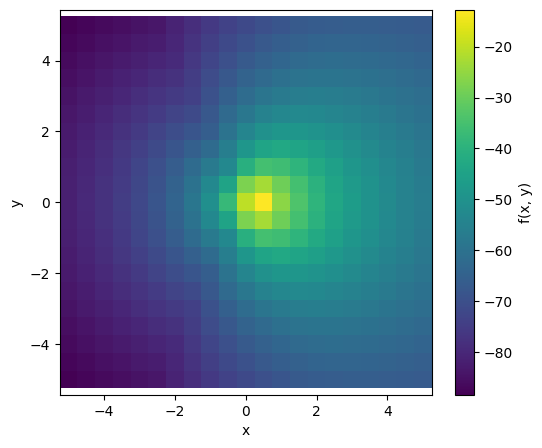

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Create grid with resolution 0.5
x = np.arange(-5, 5.5, 0.5)
y = np.arange(-5, 5.5, 0.5)
X, Y = np.meshgrid(x, y)

# Custom function
def f(x, y):
    return rssi(scanner_pose, RigidTransform.from_components([x, y, 0], rot_id))
                
# Compute Z values
Z = np.vectorize(f)(X,Y)

# Create 3D surface plot
plt.figure(figsize=(6, 5))
plt.pcolormesh(X, Y, Z, shading='auto')
plt.colorbar(label='f(x, y)')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()